# DPA on Firmware Implementation of MAGMA

## MAGMA Trace Capture

In [2]:
SCOPETYPE = 'CWNANO' # options: OPENADC, CWNANO  
PLATFORM = 'CWNANO' # options: CWLITEXMEGA/CW308_XMEGA, CWLITEARM/CW308_STM32F3, CWNANO 
CRYPTO_TARGET='MAGMA'
SS_VER='SS_VER_1_1'

In [3]:
%run "../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍


In [4]:
scope.adc.samples = 10000 #options: 96000 for CW-PRO (CW1200), 24400 for CW-Lite, 131070 for CW-Husky

In [5]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER"
cd ../../firmware/mcu/simpleserial-magma
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3

Building for platform CWNANO with CRYPTO_TARGET=MAGMA
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:13.2.rel1-2) 13.2.1 20231009
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Size after:
   text	   data	    bss	    dec	    hex	filename
   5464	     16	   1560	   7040	   1b80	simpleserial-magma-CWNANO.elf
+--------------------------------------------------------
+ Built for platform CWNANO Built-in Target (STM32F030) with:
+ CRYPTO_TARGET = MAGMA
+ CRYPTO_OPTIONS = AES128C
+--------------------------------------------------------


In [7]:
cw.program_target(scope, prog, "../../firmware/mcu/simpleserial-magma/simpleserial-magma-{}.hex".format(PLATFORM))

Detected known STMF32: STM32F03xx4/03xx6
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5479 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5479 bytes


In [10]:
from tqdm.notebook import trange
import numpy as np
import time
from os import urandom

trace_array = []
textin_array = []

text = urandom(8)

N = 300

for i in trange(N, desc='Capturing traces'):
    scope.arm()
    
    target.simpleserial_write('p', text)
    
    ret = scope.capture()
    if ret:
        print("Target timed out!")
        continue
    
    response = target.simpleserial_read('r', 8)
    
    trace_array.append(scope.get_last_trace())
    textin_array.append(text)
    
    text = urandom(8)
    
trace_array = np.array(trace_array)

Capturing traces:   0%|          | 0/300 [00:00<?, ?it/s]

In [11]:
scope.dis()
target.dis()

In [12]:
assert len(trace_array) == N
print("✔️ OK to continue!")

✔️ OK to continue!


Again, let's quickly plot a trace to make sure everything looks as expected:

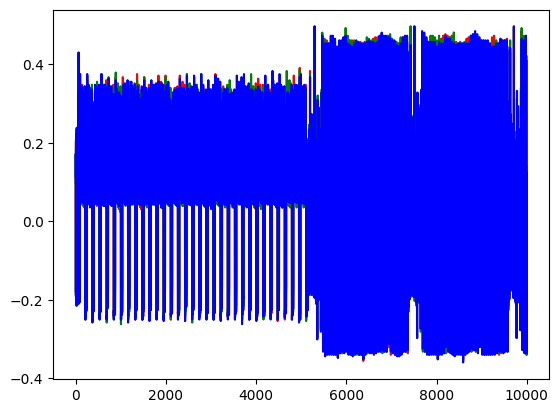

In [13]:
%matplotlib notebook
%matplotlib inline
import matplotlib.pylab as plt

plt.figure()
plt.plot(trace_array[0], 'r')
plt.plot(trace_array[N//2], 'g')
plt.plot(trace_array[N-1], 'b')
plt.show()

## Differential Attack Implementaiton

In [14]:
import numpy as np
from tqdm.notebook import trange, tqdm

# Все 8 S-блоков ГОСТ "Магма" (ГОСТ Р 34.12-2015)
sbox = [
    [0xC, 0x4, 0x6, 0x2, 0xA, 0x5, 0xB, 0x9, 0xE, 0x8, 0xD, 0x7, 0x0, 0x3, 0xF, 0x1],  # S1
    [0x6, 0x8, 0x2, 0x3, 0x9, 0xA, 0x5, 0xC, 0x1, 0xE, 0x4, 0x7, 0xB, 0xD, 0x0, 0xF],  # S2
    [0xB, 0x3, 0x5, 0x8, 0x2, 0xF, 0xA, 0xD, 0xE, 0x1, 0x7, 0x4, 0xC, 0x9, 0x6, 0x0],  # S3
    [0xC, 0x8, 0x2, 0x1, 0xD, 0x4, 0xF, 0x6, 0x7, 0x0, 0xA, 0x5, 0x3, 0xE, 0x9, 0xB],  # S4
    [0x7, 0xF, 0x5, 0xA, 0x8, 0x1, 0x6, 0xD, 0x0, 0x9, 0x3, 0xE, 0xB, 0x4, 0x2, 0xC],  # S5
    [0x5, 0xD, 0xF, 0x6, 0x9, 0x2, 0xC, 0xA, 0xB, 0x7, 0x8, 0x1, 0x4, 0x3, 0xE, 0x0],  # S6
    [0x8, 0xE, 0x2, 0x5, 0x6, 0x9, 0x1, 0xC, 0xF, 0x4, 0xB, 0x0, 0xD, 0xA, 0x3, 0x7],  # S7
    [0x1, 0x7, 0xE, 0xD, 0x0, 0x5, 0x8, 0x3, 0x4, 0xF, 0xA, 0x6, 0x9, 0xC, 0xB, 0x2]   # S8
]

bitnum = 0  # Анализируемый бит (0 = младший)
key_guess = np.zeros(32, dtype=np.uint8)  # 32-байтный ключ (256 бит)

def magma_sbox_layer(byte, sbox_num):
    """Применяет S-блок к 4-битному полубайту."""
    return sbox[sbox_num][byte & 0xF]

for byte_pos in tqdm(range(32), desc="Key bytes"):  # 32 байта = 256 бит
    diffs = []
    
    for guess in trange(256, desc=f"Byte {byte_pos} guess", leave=False):
        group1, group0 = [], []

        for i in range(len(textin_array)):
            input_byte = textin_array[i][byte_pos % 8]  # Магма использует 8 подключей по 32 бита
            sbox_num = byte_pos % 8  # Выбор S-блока (0-7)
            hyp = magma_sbox_layer(input_byte ^ guess, sbox_num)

            if (hyp >> bitnum) & 1:
                group1.append(trace_array[i])
            else:
                group0.append(trace_array[i])

        if len(group1) == 0 or len(group0) == 0:
            diffs.append(0)
            continue

        dom = np.abs(np.mean(group1, axis=0) - np.mean(group0, axis=0))
        peak = np.max(dom)
        diffs.append(peak)

    key_guess[byte_pos] = np.argmax(diffs)

print("Recovered key (hex):", ' '.join(f"{x:02X}" for x in key_guess))


Key bytes:   0%|          | 0/32 [00:00<?, ?it/s]

Byte 0 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 1 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 2 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 3 guess:   0%|          | 0/256 [00:00<?, ?it/s]

...

Byte 28 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 29 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 30 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Byte 31 guess:   0%|          | 0/256 [00:00<?, ?it/s]

Recovered key (hex): 08 00 03 0D 09 00 0C 0E 08 00 03 0D 09 00 0C 0E 08 00 03 0D 09 00 0C 0E 08 00 03 0D 09 00 0C 0E


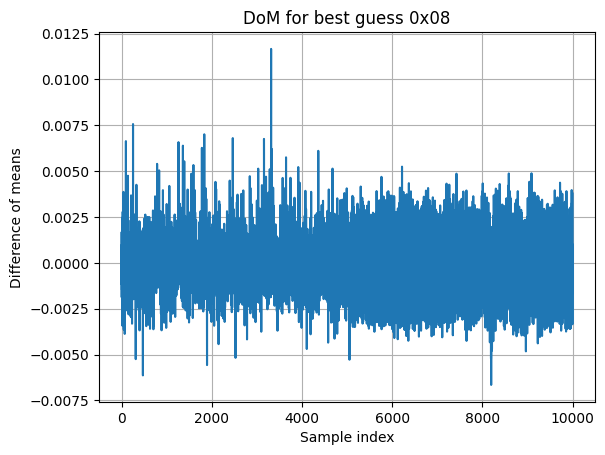

In [ ]:
import matplotlib.pyplot as plt
group1 = []
group0 = []
sbox_num = 0  # выбираем первый S-блок

for i in range(len(textin_array)):
    hyp_val = magma_sbox_layer(textin_array[i][0] ^ key_guess[0], sbox_num)
    if ((hyp_val >> bitnum) & 1):
        group1.append(trace_array[i])
    else:
        group0.append(trace_array[i])

dom = np.mean(group1, axis=0) - np.mean(group0, axis=0)

plt.figure()
plt.plot(dom)
plt.title(f"DoM for best guess 0x{key_guess[0]:02X}")
plt.xlabel("Sample index")
plt.ylabel("Difference of means")
plt.grid()
plt.show()


With one final check to make sure you've got the correct key:

In [ ]:
key = [0x6c,0xec,0xc6,0x7f,0x28,0x7d,0x08,0x3d,
       0xeb,0x87,0x66,0xf0,0x73,0x8b,0x36,0xcf,
       0x16,0x4e,0xd9,0xb2,0x46,0x95,0x10,0x90,
       0x86,0x9d,0x08,0x28,0x5d,0x2e,0x19,0x3b]

for bnum in range(32):
    assert best_guess[bnum] == key[bnum], \
    "Byte {} failed, expected {:02X} got {:02X}".format(bnum, key[bnum], best_guess[bnum])
print("✔️ OK to continue!")

IndexError: invalid index to scalar variable.

: 

: 